In [1]:
import pandas as pd

# Load German Credit dataset
df = pd.read_csv("data/german.data", sep=" ", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [5]:
columns = [
    "status", "duration", "credit_history", "purpose", "amount",
    "savings", "employment", "installment_rate", "personal_status",
    "other_debtors", "residence_time", "property", "age",
    "other_installments", "housing", "existing_credits", "job",
    "people_liable", "telephone", "foreign_worker", "default"
]

df.columns = columns
df.head()


,status,duration,credit_history,purpose,amount,savings,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,people_liable,telephone,foreign_worker,default
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [6]:
df.shape
df.info()
df.describe()
df['default'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   status              1000 non-null   object
 1   duration            1000 non-null   int64 
 2   credit_history      1000 non-null   object
 3   purpose             1000 non-null   object
 4   amount              1000 non-null   int64 
 5   savings             1000 non-null   object
 6   employment          1000 non-null   object
 7   installment_rate    1000 non-null   int64 
 8   personal_status     1000 non-null   object
 9   other_debtors       1000 non-null   object
 10  residence_time      1000 non-null   int64 
 11  property            1000 non-null   object
 12  age                 1000 non-null   int64 
 13  other_installments  1000 non-null   object
 14  housing             1000 non-null   object
 15  existing_credits    1000 non-null   int64 
 16  job                 1000 

default
1    700
2    300
Name: count, dtype: int64

In [7]:
#Convert classification target to 0/1
df["default_binary"] = (df["default"] == 2).astype(int)
df["default_binary"].value_counts()


default_binary
0    700
1    300
Name: count, dtype: int64

In [8]:
df.shape
df.dtypes
df["default_binary"].value_counts(normalize=True)


default_binary
0    0.7
1    0.3
Name: proportion, dtype: float64

In [9]:
#Show statistics for numeric columns only; mean (average), min/max, std (spread), quartiles (25%, 50%, 75%)
df[["amount","duration","age","installment_rate","residence_time","existing_credits","people_liable"]].describe()

,amount,duration,age,installment_rate,residence_time,existing_credits,people_liable
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3271.258000,20.903000,35.546000,2.973000,2.845000,1.407000,1.155000
std,2822.736876,12.058814,11.375469,1.118715,1.103718,0.577654,0.362086
min,250.000000,4.000000,19.000000,1.000000,1.000000,1.000000,1.000000
25%,1365.500000,12.000000,27.000000,2.000000,2.000000,1.000000,1.000000
50%,2319.500000,18.000000,33.000000,3.000000,3.000000,1.000000,1.000000
75%,3972.250000,24.000000,42.000000,4.000000,4.000000,2.000000,1.000000
max,18424.000000,72.000000,75.000000,4.000000,4.000000,4.000000,2.000000


In [10]:
#Check class imbalance; how many good and how many bad clients
df["default_binary"].value_counts()

default_binary
0    700
1    300
Name: count, dtype: int64

In [11]:
#For categorical columns only; Counts how many unique categories each has
df.select_dtypes(include="object").nunique().sort_values(ascending=False)

purpose               10
credit_history         5
savings                5
employment             5
status                 4
personal_status        4
property               4
job                    4
other_debtors          3
other_installments     3
housing                3
telephone              2
foreign_worker         2
dtype: int64

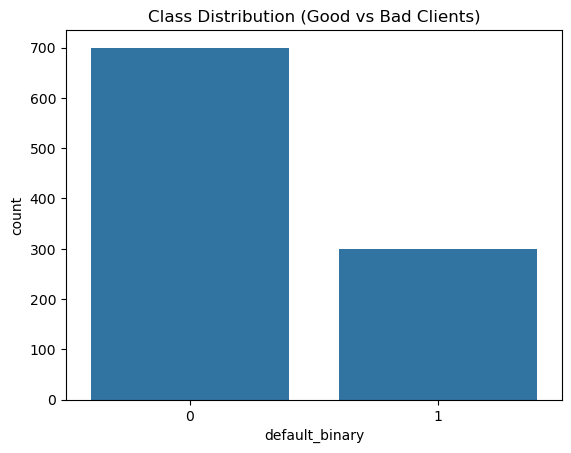

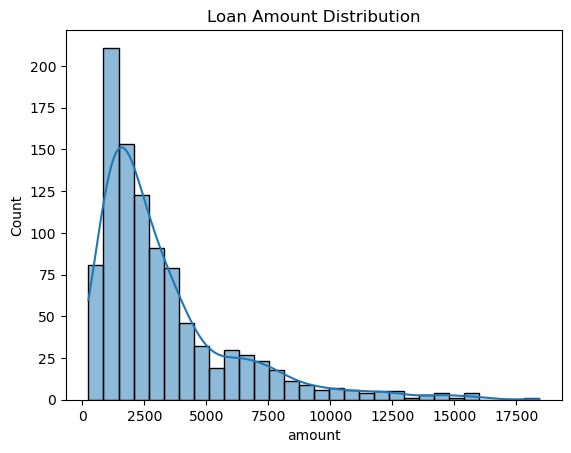

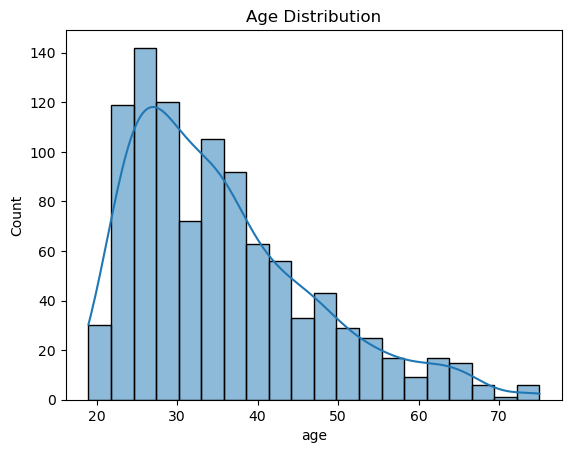

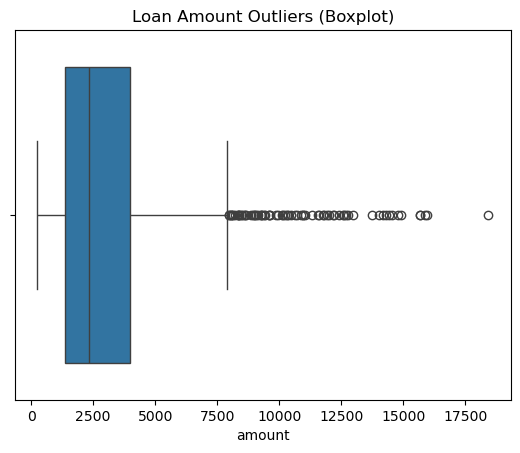

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# create figures folder automatically (if not exists)
import os
os.makedirs("figures", exist_ok=True)


# 1. Class distribution plot; show imbalance visually
sns.countplot(x="default_binary", data=df)
plt.title("Class Distribution (Good vs Bad Clients)")
plt.savefig("figures/class_distribution.png")
plt.show()


# 2. Loan amount distribution; see skewness and extreme values
sns.histplot(df["amount"], bins=30, kde=True)
plt.title("Loan Amount Distribution")
plt.savefig("figures/amount_distribution.png")
plt.show()


# 3. Age distribution; understand age spread
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.savefig("figures/age_distribution.png")
plt.show()


# 4. Boxplot for outliers; visually detect extreme loans
sns.boxplot(x=df["amount"])
plt.title("Loan Amount Outliers (Boxplot)")
plt.savefig("figures/amount_outliers.png")
plt.show()


In [13]:
# Check number of missing values per column; verify if dataset has NaN values that need cleaning
df.isnull().sum()


status                0
duration              0
credit_history        0
purpose               0
amount                0
savings               0
employment            0
installment_rate      0
personal_status       0
other_debtors         0
residence_time        0
property              0
age                   0
other_installments    0
housing               0
existing_credits      0
job                   0
people_liable         0
telephone             0
foreign_worker        0
default               0
default_binary        0
dtype: int64

In [14]:
# Show quantiles to detect extreme values statistically; identify how far extreme loans are from typical values
df["amount"].quantile([0.25, 0.5, 0.75, 0.95, 0.99])


0.25     1365.50
0.50     2319.50
0.75     3972.25
0.95     9162.70
0.99    14180.39
Name: amount, dtype: float64

In [15]:
# Convert categorical columns into numeric dummy variables; ML models need numbers, not text categories
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.shape


(1000, 50)

In [16]:
# Compute correlation of ALL numeric features with the target; find which predictors influence default the most
corr_with_target = df_encoded.corr()["default_binary"].sort_values(ascending=False)

corr_with_target


default                    1.000000
default_binary             1.000000
duration                   0.214927
amount                     0.154739
credit_history_A31         0.134448
property_A124              0.125750
status_A12                 0.119581
employment_A72             0.106397
housing_A153               0.081556
personal_status_A92        0.075493
installment_rate           0.072404
purpose_A46                0.070088
other_debtors_A102         0.062728
other_installments_A142    0.050523
credit_history_A32         0.043722
job_A174                   0.040559
purpose_A49                0.036129
purpose_A410               0.028058
savings_A62                0.022255
purpose_A42                0.020971
purpose_A45                0.020828
credit_history_A33         0.012325
property_A123              0.011121
employment_A73             0.010603
purpose_A44                0.008016
property_A122              0.007238
residence_time             0.002967
people_liable             -0

In [17]:
# Show strongest positive correlations (more likely default)
corr_with_target.head(15)

default                    1.000000
default_binary             1.000000
duration                   0.214927
amount                     0.154739
credit_history_A31         0.134448
property_A124              0.125750
status_A12                 0.119581
employment_A72             0.106397
housing_A153               0.081556
personal_status_A92        0.075493
installment_rate           0.072404
purpose_A46                0.070088
other_debtors_A102         0.062728
other_installments_A142    0.050523
credit_history_A32         0.043722
Name: default_binary, dtype: float64

In [18]:
# Show strongest negative correlations (less likely default)
corr_with_target.tail(15)

other_debtors_A103        -0.055039
employment_A75            -0.059733
savings_A63               -0.070954
employment_A74            -0.075980
personal_status_A93       -0.080677
foreign_worker_A202       -0.082079
savings_A64               -0.085749
age                       -0.091127
purpose_A41               -0.099791
purpose_A43               -0.106922
other_installments_A143   -0.113285
savings_A65               -0.129238
housing_A152              -0.134589
credit_history_A34        -0.181713
status_A14                -0.322436
Name: default_binary, dtype: float64

In [19]:
# -----------------------------
# FEATURE SELECTION (Top 13 predictors)
# -----------------------------
# After One-Hot Encoding we now have ~50 columns.
# Too many predictors → noise, overfitting, hard interpretation.
# So we keep only the most meaningful ones based on:
# 1) strongest correlation with default
# 2) financial logic

selected_features = [
    "duration",          # loan length (longer → riskier)
    "amount",            # loan amount (higher → riskier)
    "installment_rate",  # monthly burden (higher → riskier)
    "age",               # older clients → usually safer
    "residence_time",    # stability indicator
    "existing_credits",  # number of current loans
    "people_liable",     # financial responsibility count
    "credit_history_A31",# weaker credit history (risk)
    "credit_history_A34",# good/critical but paid → safer
    "housing_A152",      # own house → safer
    "savings_A64",       # higher savings → safer
    "employment_A72",    # short employment → risk
    "status_A14"         # no checking account (profile indicator)
]

# X = predictors (inputs for models)
X = df_encoded[selected_features]

# y = target (what we predict)
y = df_encoded["default_binary"]

# Check shapes to confirm everything loaded correctly
X.shape, y.shape


((1000, 13), (1000,))

In [20]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
# WHY:
# train : model learns patterns
# test : we evaluate on unseen data (prevents cheating/overfitting)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% test, 80% train (standard practice)
    random_state=42,   # reproducibility
    stratify=y         # keep same class balance (VERY important for imbalanced data)
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((800, 13), (200, 13), (800,), (200,))

In [21]:
# Import Decision Tree classifier
# DECISION TREE: train a simple interpretable model (baseline)
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=4, random_state=42)  # limit depth to reduce overfitting
dt.fit(X_train, y_train)  # learn patterns from the training data


DecisionTreeClassifier(max_depth=4, random_state=42)

In [22]:
# DECISION TREE: evaluate predictions on unseen test data
from sklearn.metrics import confusion_matrix, classification_report

y_pred_dt = dt.predict(X_test)  # predicted class (0/1)

cm_dt = confusion_matrix(y_test, y_pred_dt)  # confusion matrix table
print("Decision Tree - Confusion Matrix:\n", cm_dt)

print("\nDecision Tree - Classification Report (Precision/Recall/F1):\n")
print(classification_report(y_test, y_pred_dt, target_names=["Good (0)", "Bad (1)"]))

Decision Tree - Confusion Matrix:
 [[116  24]
 [ 34  26]]

Decision Tree - Classification Report (Precision/Recall/F1):

              precision    recall  f1-score   support

    Good (0)       0.77      0.83      0.80       140
     Bad (1)       0.52      0.43      0.47        60

    accuracy                           0.71       200
   macro avg       0.65      0.63      0.64       200
weighted avg       0.70      0.71      0.70       200



In [23]:
# DECISION TREE: evaluate predictions on unseen test data
from sklearn.metrics import confusion_matrix, classification_report

y_pred_dt = dt.predict(X_test)  # predicted class (0/1)

cm_dt = confusion_matrix(y_test, y_pred_dt)  # confusion matrix table
print("Decision Tree - Confusion Matrix:\n", cm_dt)

print("\nDecision Tree - Classification Report (Precision/Recall/F1):\n")
print(classification_report(y_test, y_pred_dt, target_names=["Good (0)", "Bad (1)"]))

Decision Tree - Confusion Matrix:
 [[116  24]
 [ 34  26]]

Decision Tree - Classification Report (Precision/Recall/F1):

              precision    recall  f1-score   support

    Good (0)       0.77      0.83      0.80       140
     Bad (1)       0.52      0.43      0.47        60

    accuracy                           0.71       200
   macro avg       0.65      0.63      0.64       200
weighted avg       0.70      0.71      0.70       200



Decision Tree - ROC-AUC: 0.7342857142857143


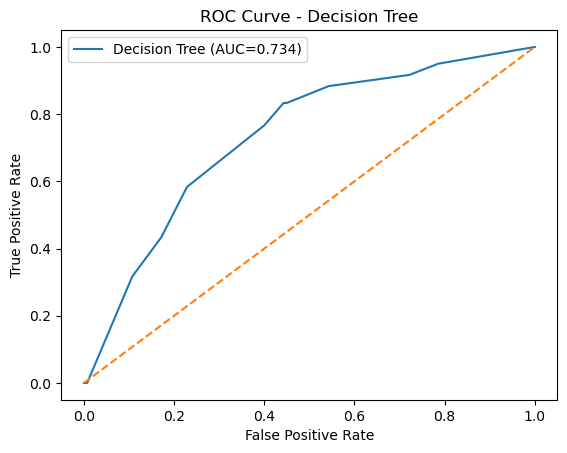

In [24]:
# DECISION TREE: compute probabilities for ROC-AUC (model confidence for class 1)
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob_dt = dt.predict_proba(X_test)[:, 1]  # probability of being "Bad (1)"  

auc_dt = roc_auc_score(y_test, y_prob_dt)  # AUC score  
print("Decision Tree - ROC-AUC:", auc_dt)

# ROC curve points (FPR vs TPR)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)  

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={auc_dt:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline line
plt.title("ROC Curve - Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("figures/decision_tree_roc.png")
plt.show()

Random Forest - Confusion Matrix:
 [[123  17]
 [ 34  26]]

Random Forest - Classification Report (Precision/Recall/F1):

              precision    recall  f1-score   support

           0       0.78      0.88      0.83       140
           1       0.60      0.43      0.50        60

    accuracy                           0.74       200
   macro avg       0.69      0.66      0.67       200
weighted avg       0.73      0.74      0.73       200

Random Forest - ROC-AUC: 0.7491666666666666


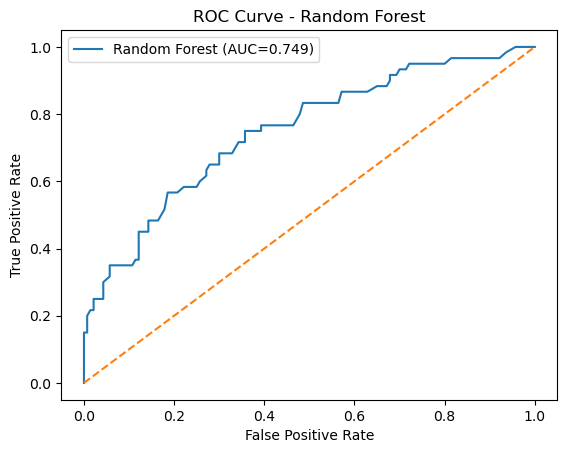

In [25]:
# RANDOM FOREST: import model + evaluation tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1) Train Random Forest model (many trees vote - usually stronger than one tree)
rf = RandomForestClassifier(
    n_estimators=200,     # number of trees (more trees = more stable)
    max_depth=None,       # let trees grow (we’ll control overfitting with other params later if needed)
    random_state=42
)

rf.fit(X_train, y_train)  # train on training set

# 2) Predict class labels on test set (0/1)
y_pred_rf = rf.predict(X_test)


# 3) Confusion Matrix + Classification Report (Precision/Recall/F1)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest - Confusion Matrix:\n", cm_rf)

print("\nRandom Forest - Classification Report (Precision/Recall/F1):\n")
print(classification_report(y_test, y_pred_rf))

# 4) ROC curve + AUC (needs probabilities, not just classes)
y_prob_rf = rf.predict_proba(X_test)[:, 1]   

auc_rf = roc_auc_score(y_test, y_prob_rf)  
print("Random Forest - ROC-AUC:", auc_rf)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)  

plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

# Save ROC image into figures folder
plt.savefig("figures/roc_random_forest.png", dpi=200, bbox_inches="tight")

plt.show()


SVM - Confusion Matrix:
 [[131   9]
 [ 34  26]]

SVM - Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.94      0.86       140
           1       0.74      0.43      0.55        60

    accuracy                           0.79       200
   macro avg       0.77      0.68      0.70       200
weighted avg       0.78      0.79      0.77       200

SVM - ROC-AUC: 0.7453571428571429


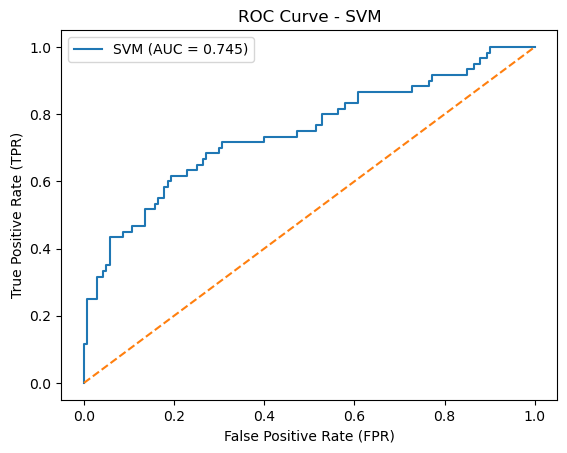

In [26]:
# SVM BASELINE (3rd classification technique); SVM often works well for binary classification, but it NEEDS feature scaling (standardization).

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import os

# Make sure figures folder exists (so plots can be saved)
os.makedirs("figures", exist_ok=True)

# 1) Build pipeline: scale features -> train SVM
# - StandardScaler(): puts all numeric features on similar scale
# - SVC(probability=True): allows predict_proba (needed for ROC/PR curves)
svm_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

# 2) Train the model on training data
svm_model.fit(X_train, y_train)

# 3) Predict class labels (0/1) on test set
y_pred_svm = svm_model.predict(X_test)

# 4) Confusion matrix + classification report (precision/recall/F1)
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("SVM - Confusion Matrix:\n", cm_svm)
print("\nSVM - Classification Report:\n", classification_report(y_test, y_pred_svm))

# 5) ROC-AUC + ROC curve
# We use predicted probabilities for the positive class (class=1 -> bad client)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

roc_auc_svm = roc_auc_score(y_test, y_prob_svm)
print("SVM - ROC-AUC:", roc_auc_svm)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc_svm:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # baseline random line
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - SVM")
plt.legend()

# Save figure into figures folder
plt.savefig("figures/roc_svm.png", dpi=300, bbox_inches="tight")
plt.show()


In [27]:
# Build a clean comparison table for DT vs RF vs SVM (same test set)
# We compare mainly the "bad" class (1), because that's the bank-critical class.

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

results = []

# Decision Tree metrics
results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision_bad(1)": precision_score(y_test, y_pred_dt, pos_label=1),
    "Recall_bad(1)": recall_score(y_test, y_pred_dt, pos_label=1),
    "F1_bad(1)": f1_score(y_test, y_pred_dt, pos_label=1),
    "ROC_AUC": roc_auc_score(y_test, y_prob_dt)
})

# Random Forest metrics
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision_bad(1)": precision_score(y_test, y_pred_rf, pos_label=1),
    "Recall_bad(1)": recall_score(y_test, y_pred_rf, pos_label=1),
    "F1_bad(1)": f1_score(y_test, y_pred_rf, pos_label=1),
    "ROC_AUC": roc_auc_score(y_test, y_prob_rf)
})

# SVM metrics
results.append({
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision_bad(1)": precision_score(y_test, y_pred_svm, pos_label=1),
    "Recall_bad(1)": recall_score(y_test, y_pred_svm, pos_label=1),
    "F1_bad(1)": f1_score(y_test, y_pred_svm, pos_label=1),
    "ROC_AUC": roc_auc_score(y_test, y_prob_svm)
})

df_compare = pd.DataFrame(results)
df_compare

,Model,Accuracy,Precision_bad(1),Recall_bad(1),F1_bad(1),ROC_AUC
0,Decision Tree,0.710,0.520000,0.433333,0.472727,0.734286
1,Random Forest,0.745,0.604651,0.433333,0.504854,0.749167
2,SVM,0.785,0.742857,0.433333,0.547368,0.745357


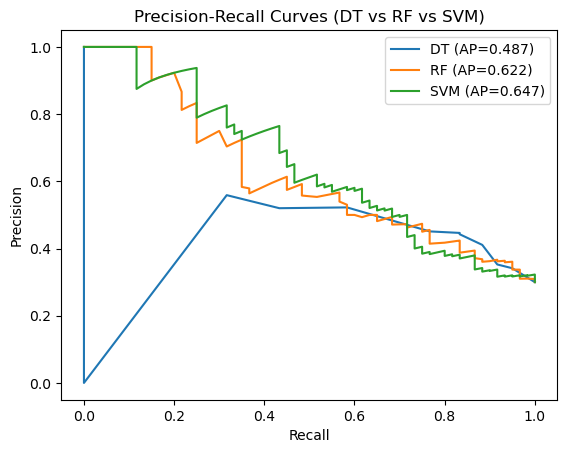

In [28]:
# Precision-Recall curve is often better than ROC for imbalanced datasets.
# We'll plot PR curves for DT, RF, SVM on the same figure and save it.

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import os

os.makedirs("figures", exist_ok=True)

plt.figure()

# Decision Tree PR
prec_dt, rec_dt, _ = precision_recall_curve(y_test, y_prob_dt)
ap_dt = average_precision_score(y_test, y_prob_dt)
plt.plot(rec_dt, prec_dt, label=f"DT (AP={ap_dt:.3f})")

# Random Forest PR
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)
plt.plot(rec_rf, prec_rf, label=f"RF (AP={ap_rf:.3f})")

# SVM PR
prec_svm, rec_svm, _ = precision_recall_curve(y_test, y_prob_svm)
ap_svm = average_precision_score(y_test, y_prob_svm)
plt.plot(rec_svm, prec_svm, label=f"SVM (AP={ap_svm:.3f})")

plt.title("Precision-Recall Curves (DT vs RF vs SVM)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.savefig("figures/pr_curves_all.png", dpi=200, bbox_inches="tight")
plt.show()



Decision Tree (balanced) - Confusion Matrix:
 [[85 55]
 [14 46]]

Decision Tree (balanced) - Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.61      0.71       140
           1       0.46      0.77      0.57        60

    accuracy                           0.66       200
   macro avg       0.66      0.69      0.64       200
weighted avg       0.74      0.66      0.67       200

Decision Tree (balanced) - ROC-AUC: 0.703333
Decision Tree (balanced) - PR-AUC (AP): 0.440183

Random Forest (balanced) - Confusion Matrix:
 [[127  13]
 [ 37  23]]

Random Forest (balanced) - Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.91      0.84       140
           1       0.64      0.38      0.48        60

    accuracy                           0.75       200
   macro avg       0.71      0.65      0.66       200
weighted avg       0.73      0.75      0.73       200

Random Fores

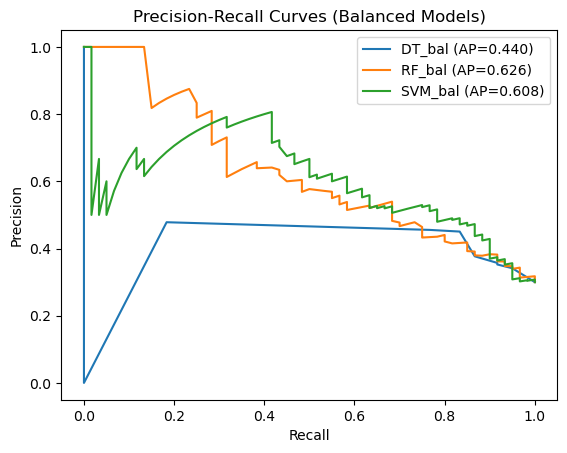

In [29]:
# PHASE 3A: class_weight='balanced'

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, precision_recall_curve, average_precision_score
)

import matplotlib.pyplot as plt
import os
import pandas as pd

os.makedirs("figures", exist_ok=True)

# Helper: evaluate any model 
def evaluate_model(name, y_test, y_pred, y_proba):
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name} - Confusion Matrix:\n", cm)
    print(f"\n{name} - Classification Report:\n", classification_report(y_test, y_pred))

    roc_auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)  # PR-AUC (Average Precision)

    print(f"{name} - ROC-AUC: {roc_auc:.6f}")
    print(f"{name} - PR-AUC (AP): {ap:.6f}")

    return cm, roc_auc, ap

# 1) Decision Tree (balanced)

dt_bal = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)
dt_bal.fit(X_train, y_train)

y_pred_dt_bal = dt_bal.predict(X_test)
y_proba_dt_bal = dt_bal.predict_proba(X_test)[:, 1]

cm_dt_bal, roc_dt_bal, ap_dt_bal = evaluate_model("Decision Tree (balanced)", y_test, y_pred_dt_bal, y_proba_dt_bal)

# 2) Random Forest (balanced)

rf_bal = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
rf_bal.fit(X_train, y_train)

y_pred_rf_bal = rf_bal.predict(X_test)
y_proba_rf_bal = rf_bal.predict_proba(X_test)[:, 1]

cm_rf_bal, roc_rf_bal, ap_rf_bal = evaluate_model("Random Forest (balanced)", y_test, y_pred_rf_bal, y_proba_rf_bal)

# 3) SVM (balanced) + scaling

svm_bal = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, class_weight="balanced", random_state=42))
])

svm_bal.fit(X_train, y_train)

y_pred_svm_bal = svm_bal.predict(X_test)
y_proba_svm_bal = svm_bal.predict_proba(X_test)[:, 1]

cm_svm_bal, roc_svm_bal, ap_svm_bal = evaluate_model("SVM (balanced)", y_test, y_pred_svm_bal, y_proba_svm_bal)

# Comparison table: Balanced models

df_balanced = pd.DataFrame([
    {"Model": "DT_balanced", "ROC_AUC": roc_dt_bal, "PR_AUC(AP)": ap_dt_bal},
    {"Model": "RF_balanced", "ROC_AUC": roc_rf_bal, "PR_AUC(AP)": ap_rf_bal},
    {"Model": "SVM_balanced", "ROC_AUC": roc_svm_bal, "PR_AUC(AP)": ap_svm_bal},
])

print("\nBalanced models summary:")
print(df_balanced)

# PR curves for balanced models (one plot)

plt.figure()

prec_dt, rec_dt, _ = precision_recall_curve(y_test, y_proba_dt_bal)
plt.plot(rec_dt, prec_dt, label=f"DT_bal (AP={ap_dt_bal:.3f})")

prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_proba_rf_bal)
plt.plot(rec_rf, prec_rf, label=f"RF_bal (AP={ap_rf_bal:.3f})")

prec_svm, rec_svm, _ = precision_recall_curve(y_test, y_proba_svm_bal)
plt.plot(rec_svm, prec_svm, label=f"SVM_bal (AP={ap_svm_bal:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Balanced Models)")
plt.legend()

plt.savefig("figures/pr_curves_balanced.png", dpi=300, bbox_inches="tight")
plt.show()


           Model  Threshold  Accuracy  Precision_bad(1)  Recall_bad(1)  \
0    RF_balanced       0.50     0.755          0.641026       0.416667   
1    RF_balanced       0.45     0.740          0.576923       0.500000   
2    RF_balanced       0.40     0.710          0.514706       0.583333   
3    RF_balanced       0.35     0.695          0.493976       0.683333   
4    RF_balanced       0.30     0.665          0.463918       0.750000   
5    RF_balanced       0.25     0.635          0.440367       0.800000   
6    RF_balanced       0.20     0.555          0.390977       0.866667   
7   SVM_balanced       0.50     0.770          0.675000       0.450000   
8   SVM_balanced       0.45     0.745          0.569231       0.616667   
9   SVM_balanced       0.40     0.720          0.526316       0.666667   
10  SVM_balanced       0.35     0.725          0.528736       0.766667   
11  SVM_balanced       0.30     0.680          0.479592       0.783333   
12  SVM_balanced       0.25     0.650 

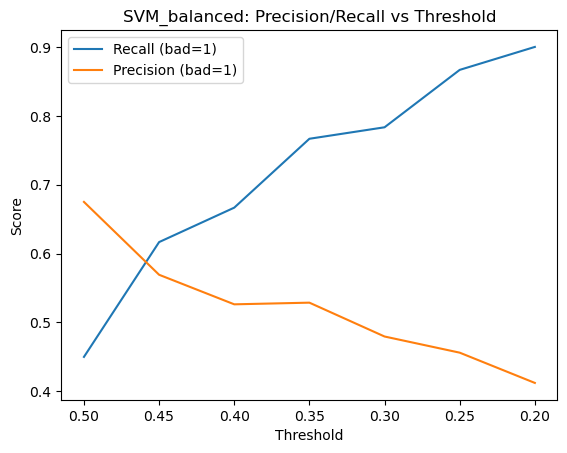

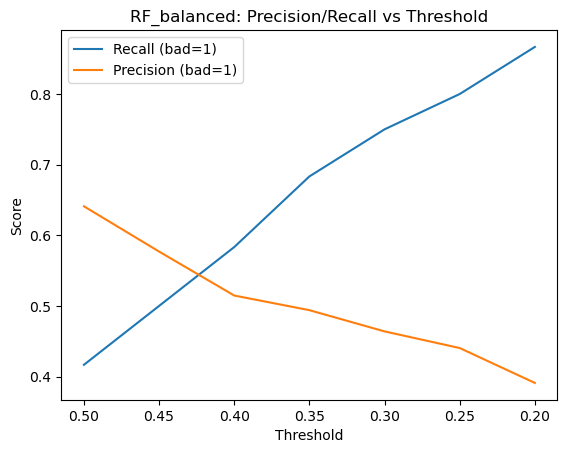

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

os.makedirs("figures", exist_ok=True)

def threshold_table(name, y_test, y_proba, thresholds):
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        rows.append({
            "Model": name,
            "Threshold": t,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision_bad(1)": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            "Recall_bad(1)": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
            "F1_bad(1)": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        })
    return pd.DataFrame(rows)

# Choosing thresholds to test
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

# We already have these from the balanced runs:
# y_proba_rf_bal, y_proba_svm_bal

df_rf_thr = threshold_table("RF_balanced", y_test, y_proba_rf_bal, thresholds)
df_svm_thr = threshold_table("SVM_balanced", y_test, y_proba_svm_bal, thresholds)

df_thr = pd.concat([df_rf_thr, df_svm_thr], ignore_index=True)
print(df_thr)

#  Plot Precision/Recall vs Threshold for SVM_balanced 
svm_part = df_thr[df_thr["Model"] == "SVM_balanced"]

plt.figure()
plt.plot(svm_part["Threshold"], svm_part["Recall_bad(1)"], label="Recall (bad=1)")
plt.plot(svm_part["Threshold"], svm_part["Precision_bad(1)"], label="Precision (bad=1)")
plt.gca().invert_xaxis()  # so lowering threshold goes to the right visually
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("SVM_balanced: Precision/Recall vs Threshold")
plt.legend()
plt.savefig("figures/svm_bal_threshold_curve.png", dpi=300, bbox_inches="tight")
plt.show()

#  Plot Precision/Recall vs Threshold for RF_balanced 
rf_part = df_thr[df_thr["Model"] == "RF_balanced"]

plt.figure()
plt.plot(rf_part["Threshold"], rf_part["Recall_bad(1)"], label="Recall (bad=1)")
plt.plot(rf_part["Threshold"], rf_part["Precision_bad(1)"], label="Precision (bad=1)")
plt.gca().invert_xaxis()
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("RF_balanced: Precision/Recall vs Threshold")
plt.legend()
plt.savefig("figures/rf_bal_threshold_curve.png", dpi=300, bbox_inches="tight")
plt.show()


Linear Regression results:
MSE:  0.007515
RMSE: 0.086687
R^2:  0.761803


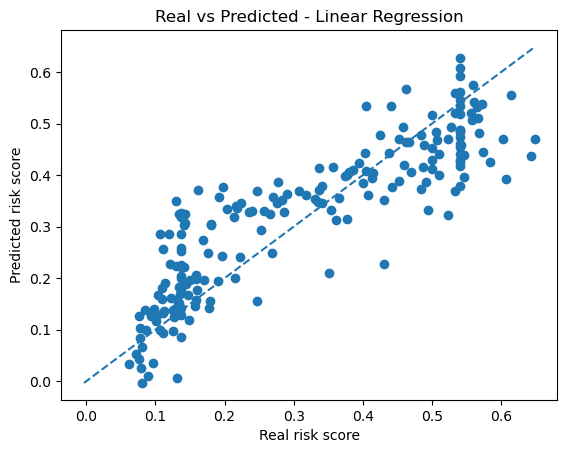


Ridge Regression results:
MSE:  0.007530
RMSE: 0.086777
R^2:  0.761305


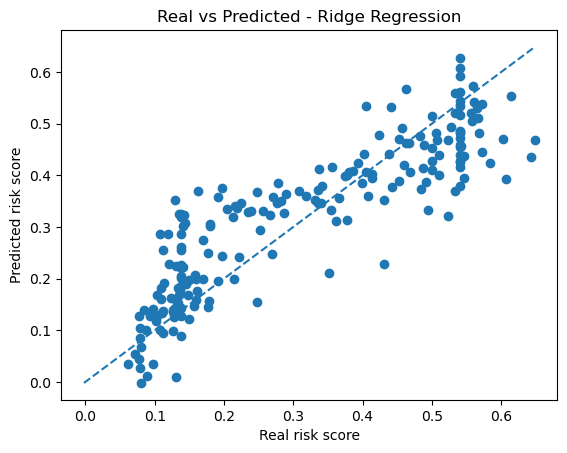


Regression summary:
               Model       MSE      RMSE        R2
0  Linear Regression  0.007515  0.086687  0.761803
1   Ridge Regression  0.007530  0.086777  0.761305


In [31]:
# 4. REGRESSION (Risk Score Proxy)
# Target: risk_score = probability of default from SVM_balanced (svm_bal)
# Models: Linear Regression + Ridge Regression
# Metrics: MSE, RMSE, R^2
# Plot: Real vs Predicted

import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge

os.makedirs("figures", exist_ok=True)

# 1) Create numeric regression target (proxy risk score)
# Use our trained balanced SVM pipeline: svm_bal
risk_score = svm_bal.predict_proba(X)[:, 1]   # probability of bad=1 (risk score)

# 2) Train/Test split for regression (keep it consistent)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, risk_score, test_size=0.2, random_state=42
)

# Helper: evaluate regression model
def eval_regression(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name} results:")
    print(f"MSE:  {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R^2:  {r2:.6f}")
    return mse, rmse, r2

# Helper: Real vs Predicted plot
def plot_real_vs_pred(name, y_true, y_pred, save_path):
    plt.figure()
    plt.scatter(y_true, y_pred)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Real risk score")
    plt.ylabel("Predicted risk score")
    plt.title(f"Real vs Predicted - {name}")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# 3) Linear Regression (baseline)

lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
y_pred_lin = lin_reg.predict(X_test_reg)

mse_lin, rmse_lin, r2_lin = eval_regression("Linear Regression", y_test_reg, y_pred_lin)
plot_real_vs_pred("Linear Regression", y_test_reg, y_pred_lin, "figures/reg_linear_real_vs_pred.png")

# 4) Ridge Regression (regularized linear model)

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_reg, y_train_reg)
y_pred_ridge = ridge.predict(X_test_reg)

mse_ridge, rmse_ridge, r2_ridge = eval_regression("Ridge Regression", y_test_reg, y_pred_ridge)
plot_real_vs_pred("Ridge Regression", y_test_reg, y_pred_ridge, "figures/reg_ridge_real_vs_pred.png")

# 5) Summary table (optional print)
import pandas as pd

df_reg = pd.DataFrame([
    {"Model": "Linear Regression", "MSE": mse_lin, "RMSE": rmse_lin, "R2": r2_lin},
    {"Model": "Ridge Regression",  "MSE": mse_ridge, "RMSE": rmse_ridge, "R2": r2_ridge},
])

print("\nRegression summary:")
print(df_reg)



SVR (RBF) results:
MSE:  0.226275
RMSE: 0.475684
R^2:  -0.077500


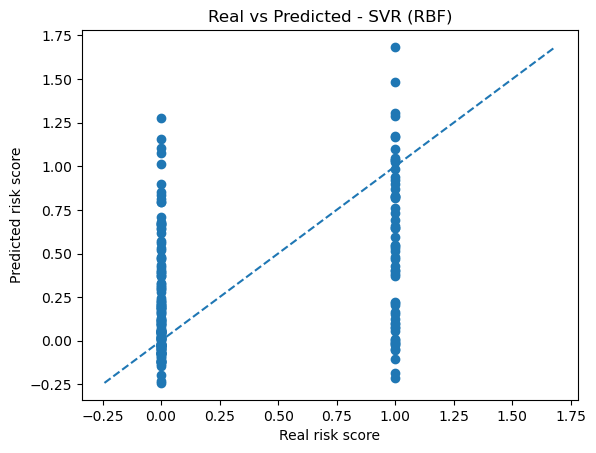

In [32]:
# SVR Regression (RBF) + Comparison Table
# Uses existing: X_train, X_test, y_train, y_test

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

os.makedirs("figures", exist_ok=True)

#  helper: evaluate any regression model 
def eval_regression(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name} results:")
    print(f"MSE:  {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R^2:  {r2:.6f}")
    return {"Model": name, "MSE": mse, "RMSE": rmse, "R2": r2}

# 1) SVR model (RBF kernel) 
# NOTE: SVR NEEDS scaling, so we use a Pipeline
svr_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.05))
])

svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

#  metrics 
svr_metrics = eval_regression("SVR (RBF)", y_test, y_pred_svr)

# plot: Real vs Predicted 
plt.figure()
plt.scatter(y_test, y_pred_svr)
mn = min(y_test.min(), y_pred_svr.min())
mx = max(y_test.max(), y_pred_svr.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Real risk score")
plt.ylabel("Predicted risk score")
plt.title("Real vs Predicted - SVR (RBF)")
plt.savefig("figures/real_vs_pred_svr.png", dpi=300, bbox_inches="tight")
plt.show()



In [33]:
# Regression comparison table
linear_metrics = {"Model":"Linear Regression", "MSE":0.007515, "RMSE":0.086687, "R2":0.761803}
ridge_metrics  = {"Model":"Ridge Regression",  "MSE":0.007530, "RMSE":0.086777, "R2":0.761305}

results = [linear_metrics, ridge_metrics, svr_metrics]

df_reg_compare = pd.DataFrame(results).sort_values("RMSE")
print(df_reg_compare)


               Model       MSE      RMSE        R2
0  Linear Regression  0.007515  0.086687  0.761803
1   Ridge Regression  0.007530  0.086777  0.761305
2          SVR (RBF)  0.226275  0.475684 -0.077500


Added risk_score column to df_clust from svm_bal.predict_proba(X)[:,1].

PCA(2D) explained variance (viz only): 0.279

KMeans metrics (k selection):
   k  inertia(SSE)  silhouette(higher=better)  davies_bouldin(lower=better)
0  2  11592.224453                   0.129702                      2.521847
1  3  10593.859346                   0.151985                      2.095056
2  4   9667.468947                   0.151063                      1.980869
3  5   8826.594558                   0.164661                      1.764878
4  6   8239.017385                   0.152580                      1.786656
5  7   7604.451846                   0.171722                      1.646408
6  8   7189.911967                   0.158540                      1.616514


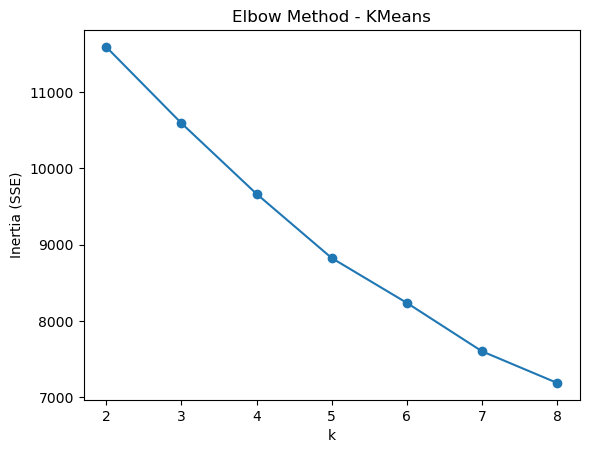

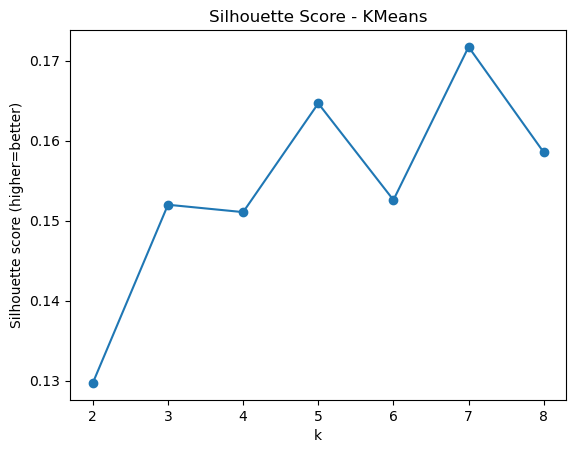

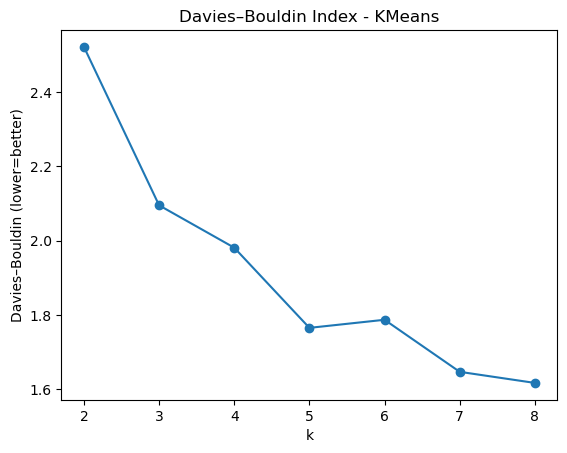


Suggested k (max silhouette): 7
Final k used for KMeans = 4


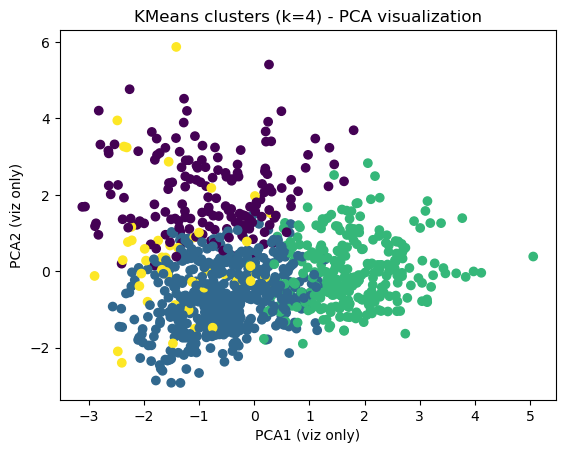


KMeans cluster sizes:
kmeans_cluster
0    164
1    512
2    275
3     49
Name: count, dtype: int64

Default rate by KMeans cluster (mean default_binary):
kmeans_cluster
3    0.571429
0    0.512195
1    0.289062
2    0.145455
Name: default_binary, dtype: float64


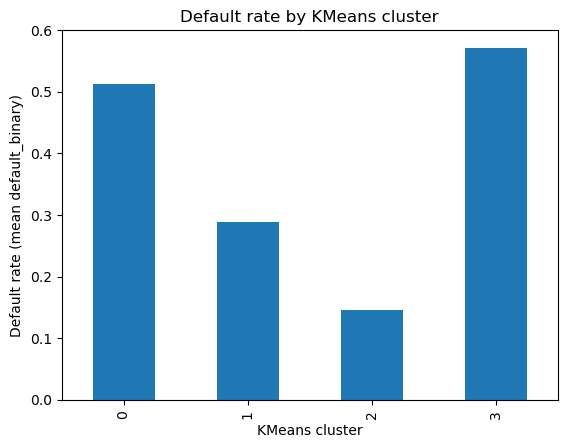


KMeans cluster profile (mean):
                 duration       amount  installment_rate        age  \
kmeans_cluster                                                        
0               38.097561  7943.042683          2.591463  35.487805   
1               17.099609  2184.761719          3.001953  33.191406   
2               17.410909  2494.916364          3.120000  39.836364   
3               22.693878  3344.877551          3.122449  36.265306   

                residence_time  existing_credits  people_liable  \
kmeans_cluster                                                    
0                     2.993902          1.420732       1.195122   
1                     2.677734          1.142578       1.111328   
2                     3.043636          1.934545       1.192727   
3                     2.979592          1.163265       1.265306   

                credit_history_A31  credit_history_A34  housing_A152  \
kmeans_cluster                                                    

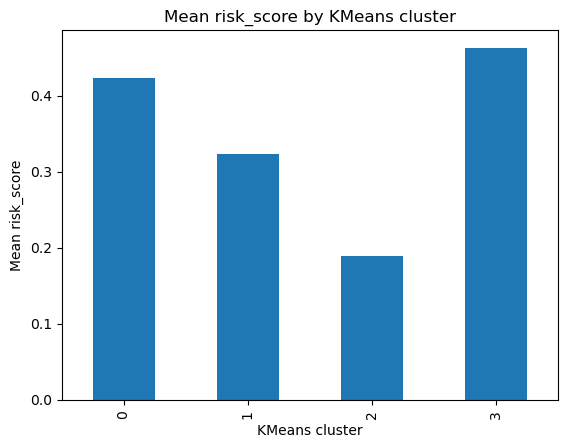


DBSCAN grid results:
   eps  min_samples  clusters(excl_noise)  noise_ratio  silhouette_non_noise
0  0.3            5                     0        1.000                   NaN
1  0.3           10                     0        1.000                   NaN
2  0.5            5                     2        0.989              0.868424
3  0.5           10                     0        1.000                   NaN
4  0.7            5                     9        0.922              0.466842
5  0.7           10                     1        0.984                   NaN
6  0.9            5                    17        0.863              0.355533
7  0.9           10                     2        0.969              0.763309
8  1.1            5                    15        0.668              0.297579
9  1.1           10                     5        0.836              0.435851

Best DBSCAN (by silhouette on non-noise): eps=0.5, min_samples=5


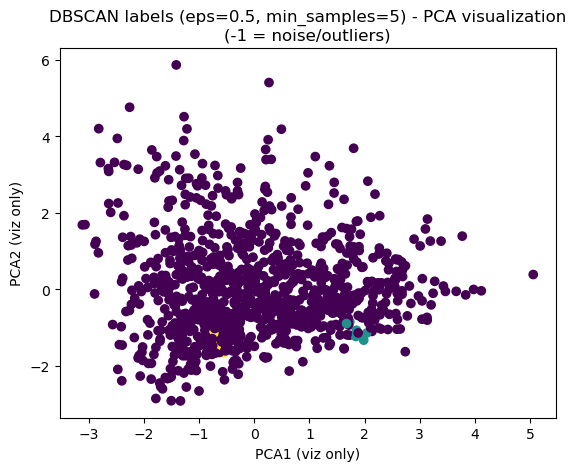


DBSCAN final summary:
Clusters (excluding noise): 2
Noise ratio: 0.989

Default rate: noise vs non-noise:
is_noise
False    0.272727
True     0.300303
Name: default_binary, dtype: float64

Mean profile (noise points):
duration                20.992922
amount                3293.809909
installment_rate         2.961577
age                     35.627907
residence_time           2.849343
existing_credits         1.405460
people_liable            1.156724
credit_history_A31       0.049545
credit_history_A34       0.290192
housing_A152             0.709808
savings_A64              0.048534
employment_A72           0.173913
status_A14               0.392315
dtype: float64

Mean profile (non-noise points):
duration                12.818182
amount                1243.636364
installment_rate         4.000000
age                     28.181818
residence_time           2.454545
existing_credits         1.545455
people_liable            1.000000
credit_history_A31       0.000000
credit_history_A34

In [34]:
# 5. CLUSTERING (K-Means + DBSCAN) + Knowledge Extraction (Credit Risk Segmentation)
# Uses: df_encoded (ONE-HOT), selected_features (our 13 predictors)
# Adds: default_binary (if missing) and risk_score (if missing)
# Metrics: Elbow (inertia), Silhouette, Davies–Bouldin
# Viz: PCA 2D for plotting only
# Saves: PNG + CSV in ./figures


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

os.makedirs("figures", exist_ok=True)

# 0) SAFETY CHECKS (using df_encoded, not df)

assert isinstance(df_encoded, pd.DataFrame), "df_encoded must exist (our one-hot encoded dataframe)."
assert isinstance(selected_features, (list, tuple)) and len(selected_features) > 0, "selected_features must exist (list)."

# Make a working copy for clustering/interpretation tables
df_clust = df_encoded.copy()

# Ensure default_binary exists as a column (0=good,1=bad)
if "default_binary" not in df_clust.columns:
    # y must exist from earlier classification
    try:
        df_clust["default_binary"] = np.array(y).astype(int)
        print("Added default_binary column to df_clust from y.")
    except Exception as e:
        raise ValueError("default_binary not found and y not available to create it.") from e

# Ensure risk_score exists as a column (continuous in [0,1]) 
if "risk_score" not in df_clust.columns:
    # svm_bal and X must exist from earlier steps
    try:
        df_clust["risk_score"] = svm_bal.predict_proba(X)[:, 1]
        print("Added risk_score column to df_clust from svm_bal.predict_proba(X)[:,1].")
    except Exception:
        print("NOTE: risk_score not added (svm_bal or X not available). This is optional.")


# 1) SELECT FEATURES FOR CLUSTERING (must exist in df_encoded)

missing_feats = [c for c in selected_features if c not in df_clust.columns]
present_feats = [c for c in selected_features if c in df_clust.columns]

if len(missing_feats) > 0:
    print("\nWARNING: Some selected_features are missing in df_encoded:")
    print(missing_feats)
    print("\nFix options:")
    print("1) Use df_encoded (not df) ✅ (we are doing that).")
    print("2) If still missing: our encoding step may differ (e.g., drop_first=True or different column names).")
    print("   - Rebuild selected_features from df_encoded.columns, or ensure get_dummies created these columns.")
    print("\nProceeding with available features only:", present_feats)

if len(present_feats) < 2:
    raise ValueError("Not enough clustering features available. Check encoding / selected_features names.")

X_all = df_clust[present_feats].copy()

# Ensure numeric
for col in present_feats:
    if not pd.api.types.is_numeric_dtype(X_all[col]):
        raise ValueError(f"Feature '{col}' is not numeric. Fix encoding before clustering.")


# 2) SCALE + PCA (PCA only for visualization)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
pca_var = float(pca.explained_variance_ratio_.sum())
print(f"\nPCA(2D) explained variance (viz only): {pca_var:.3f}")


# 3) K-MEANS: choose k using Elbow + Silhouette + Davies–Bouldin

k_values = range(2, 9)  # 2..8
inertias, sil_scores, db_scores = [], [], []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

df_kmeans_metrics = pd.DataFrame({
    "k": list(k_values),
    "inertia(SSE)": inertias,
    "silhouette(higher=better)": sil_scores,
    "davies_bouldin(lower=better)": db_scores
})

print("\nKMeans metrics (k selection):")
print(df_kmeans_metrics)
df_kmeans_metrics.to_csv("figures/kmeans_k_metrics.csv", index=False)

# Elbow
plt.figure()
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method - KMeans")
plt.savefig("figures/kmeans_elbow.png", dpi=300, bbox_inches="tight")
plt.show()

# Silhouette
plt.figure()
plt.plot(list(k_values), sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score (higher=better)")
plt.title("Silhouette Score - KMeans")
plt.savefig("figures/kmeans_silhouette.png", dpi=300, bbox_inches="tight")
plt.show()

# Davies–Bouldin
plt.figure()
plt.plot(list(k_values), db_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Davies–Bouldin (lower=better)")
plt.title("Davies–Bouldin Index - KMeans")
plt.savefig("figures/kmeans_davies_bouldin.png", dpi=300, bbox_inches="tight")
plt.show()

suggested_k = int(df_kmeans_metrics.loc[df_kmeans_metrics["silhouette(higher=better)"].idxmax(), "k"])
print("\nSuggested k (max silhouette):", suggested_k)

# Choose final_k (keep interpretable)
final_k = min(suggested_k, 4)  # typical credit segmentation: 2..4 clusters
# If you want manual override, uncomment:
# final_k = 3
print("Final k used for KMeans =", final_k)

kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
df_clust["kmeans_cluster"] = kmeans_labels

# PCA plot of clusters
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels)
plt.xlabel("PCA1 (viz only)")
plt.ylabel("PCA2 (viz only)")
plt.title(f"KMeans clusters (k={final_k}) - PCA visualization")
plt.savefig("figures/kmeans_clusters_pca.png", dpi=300, bbox_inches="tight")
plt.show()


# 4) KNOWLEDGE EXTRACTION (make clustering meaningful)

cluster_sizes = df_clust["kmeans_cluster"].value_counts().sort_index()
default_rate_by_cluster = df_clust.groupby("kmeans_cluster")["default_binary"].mean().sort_values(ascending=False)

print("\nKMeans cluster sizes:")
print(cluster_sizes)

print("\nDefault rate by KMeans cluster (mean default_binary):")
print(default_rate_by_cluster)

cluster_sizes.to_csv("figures/kmeans_cluster_sizes.csv")
default_rate_by_cluster.to_csv("figures/kmeans_default_rate.csv")

# Bar chart: default rate
plt.figure()
default_rate_by_cluster.sort_index().plot(kind="bar")
plt.xlabel("KMeans cluster")
plt.ylabel("Default rate (mean default_binary)")
plt.title("Default rate by KMeans cluster")
plt.savefig("figures/kmeans_default_rate_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Feature profiles
profile_mean = df_clust.groupby("kmeans_cluster")[present_feats].mean()
profile_median = df_clust.groupby("kmeans_cluster")[present_feats].median()

print("\nKMeans cluster profile (mean):")
print(profile_mean)

print("\nKMeans cluster profile (median):")
print(profile_median)

profile_mean.to_csv("figures/kmeans_profile_mean.csv")
profile_median.to_csv("figures/kmeans_profile_median.csv")

# risk_score per cluster (if available)
if "risk_score" in df_clust.columns:
    risk_by_cluster = df_clust.groupby("kmeans_cluster")["risk_score"].mean().sort_values(ascending=False)
    print("\nMean risk_score by KMeans cluster:")
    print(risk_by_cluster)
    risk_by_cluster.to_csv("figures/kmeans_risk_score_mean.csv")

    plt.figure()
    risk_by_cluster.sort_index().plot(kind="bar")
    plt.xlabel("KMeans cluster")
    plt.ylabel("Mean risk_score")
    plt.title("Mean risk_score by KMeans cluster")
    plt.savefig("figures/kmeans_risk_score_bar.png", dpi=300, bbox_inches="tight")
    plt.show()


# 5) DBSCAN: grid search + treat mainly as noise/outlier detector

eps_values = [0.3, 0.5, 0.7, 0.9, 1.1]
min_samples_values = [5, 10]

dbscan_rows = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = float(np.mean(labels == -1))

        sil_non_noise = np.nan
        if n_clusters >= 2:
            mask = labels != -1
            if mask.sum() > 10 and len(set(labels[mask])) >= 2:
                sil_non_noise = silhouette_score(X_scaled[mask], labels[mask])

        dbscan_rows.append({
            "eps": eps,
            "min_samples": ms,
            "clusters(excl_noise)": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette_non_noise": sil_non_noise
        })

df_dbscan = pd.DataFrame(dbscan_rows)
print("\nDBSCAN grid results:")
print(df_dbscan)
df_dbscan.to_csv("figures/dbscan_grid_results.csv", index=False)

valid = df_dbscan.dropna(subset=["silhouette_non_noise"]).copy()

if len(valid) > 0:
    best = valid.sort_values("silhouette_non_noise", ascending=False).iloc[0]
    best_eps = float(best["eps"])
    best_ms = int(best["min_samples"])
    print(f"\nBest DBSCAN (by silhouette on non-noise): eps={best_eps}, min_samples={best_ms}")

    dbscan_final = DBSCAN(eps=best_eps, min_samples=best_ms)
    dbscan_labels = dbscan_final.fit_predict(X_scaled)
    df_clust["dbscan_label"] = dbscan_labels

    # PCA visualization (-1 = noise)
    plt.figure()
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=dbscan_labels)
    plt.xlabel("PCA1 (viz only)")
    plt.ylabel("PCA2 (viz only)")
    plt.title(f"DBSCAN labels (eps={best_eps}, min_samples={best_ms}) - PCA visualization\n(-1 = noise/outliers)")
    plt.savefig("figures/dbscan_clusters_pca.png", dpi=300, bbox_inches="tight")
    plt.show()

    n_clusters_final = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    noise_ratio_final = float(np.mean(dbscan_labels == -1))
    print("\nDBSCAN final summary:")
    print("Clusters (excluding noise):", n_clusters_final)
    print("Noise ratio:", noise_ratio_final)

    # Default rate: noise vs non-noise
    noise_vs_non = df_clust.assign(is_noise=(df_clust["dbscan_label"] == -1)).groupby("is_noise")["default_binary"].mean()
    print("\nDefault rate: noise vs non-noise:")
    print(noise_vs_non)
    noise_vs_non.to_csv("figures/dbscan_noise_vs_non_default_rate.csv")

    # Feature mean profile: noise vs non-noise
    noise_mean = df_clust[df_clust["dbscan_label"] == -1][present_feats].mean()
    non_noise_mean = df_clust[df_clust["dbscan_label"] != -1][present_feats].mean()

    print("\nMean profile (noise points):")
    print(noise_mean)
    print("\nMean profile (non-noise points):")
    print(non_noise_mean)

    noise_mean.to_csv("figures/dbscan_noise_profile_mean.csv")
    non_noise_mean.to_csv("figures/dbscan_non_noise_profile_mean.csv")

else:
    print("\nDBSCAN did not produce stable >=2 clusters in this grid.")
    print("Use DBSCAN mainly as outlier/noise detector; discuss sensitivity to eps/min_samples.")

# 6) SAVE FINAL WORKING DATAFRAME 
df_clust.to_csv("figures/df_with_clusters.csv", index=False)
print("\nSaved df_with_clusters.csv in figures/ (includes kmeans_cluster, optional dbscan_label, default_binary, risk_score).")
print("\nDONE. Check ./figures for plots + CSV tables.")


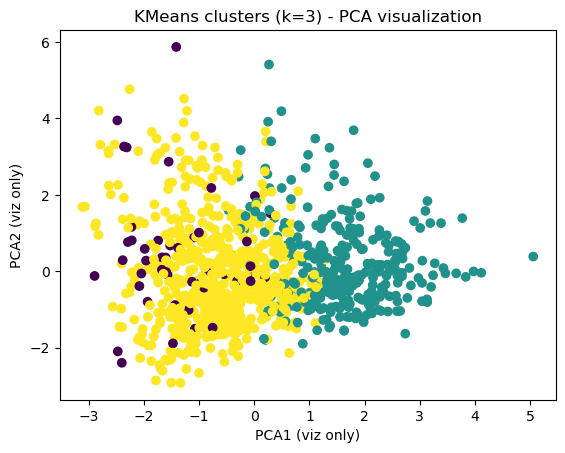

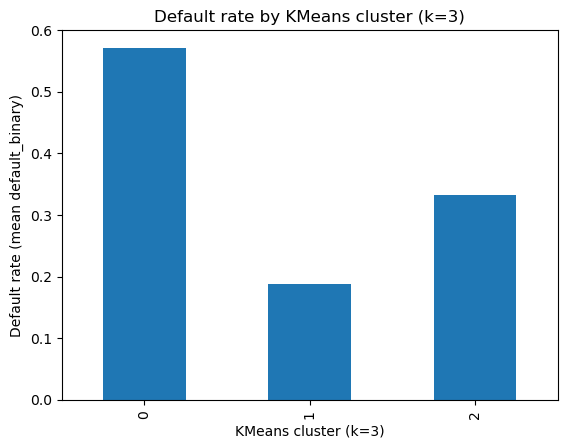

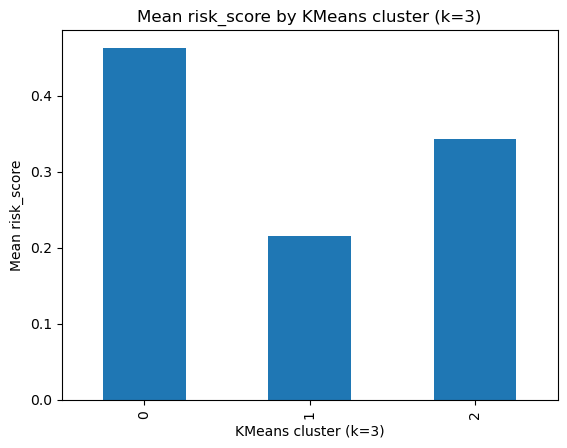

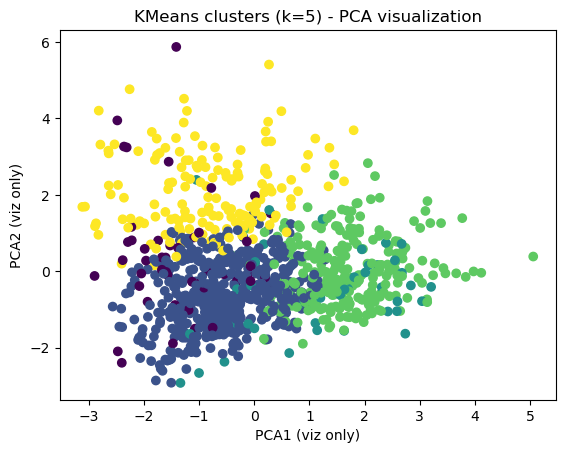

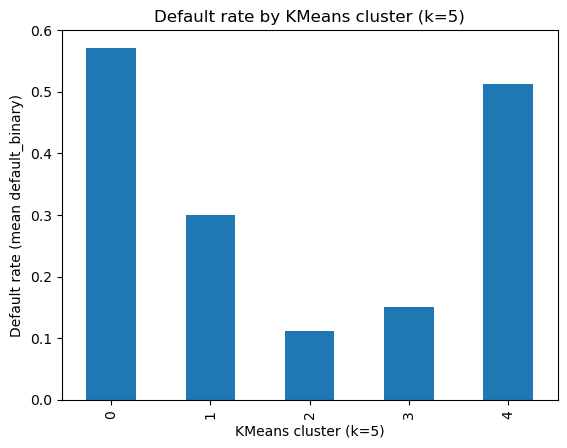

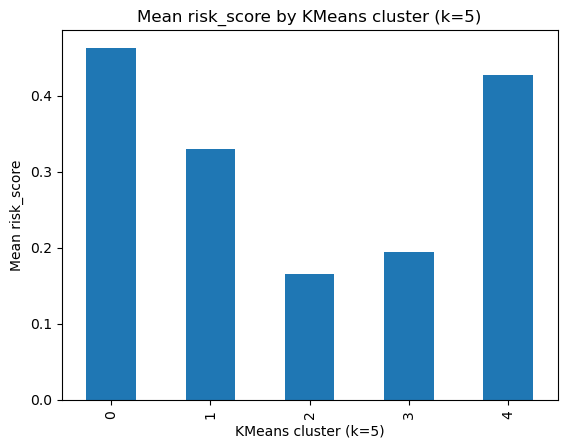


KMeans quick comparison (k=3 vs k=5):
   k  inertia(SSE)  silhouette  davies_bouldin  min_default_rate  \
0  3  10593.859346    0.151985        2.095056          0.187702   
1  5   8826.594558    0.164661        1.764878          0.111111   

   max_default_rate  default_rate_gap(max-min)  \
0          0.571429                   0.383726   
1          0.571429                   0.460317   

                           clusters_sizes  
0                 {0: 49, 1: 309, 2: 642}  
1  {0: 49, 1: 497, 2: 45, 3: 253, 4: 156}  

Saved: figures/kmeans_k3_vs_k5_comparison.csv


In [35]:
# QUICK K CHECK: k = 3 and k = 5
# Uses existing objects from our final clustering notebook:
# - X_scaled (scaled features)
# - X_2d (PCA 2D for viz)
# - df_clust (dataframe copy)
# - default_binary column in df_clust
# - optional risk_score column in df_clust
# Saves plots + CSV into ./figures

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

os.makedirs("figures", exist_ok=True)

def run_kmeans_k(k, X_scaled, X_2d, df_clust):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    # Metrics
    inertia = km.inertia_
    sil = silhouette_score(X_scaled, labels)
    dbi = davies_bouldin_score(X_scaled, labels)

    # Attach labels to a temp df (avoid overwriting our main)
    tmp = df_clust.copy()
    tmp[f"kmeans_k{k}"] = labels

    # Cluster sizes
    sizes = tmp[f"kmeans_k{k}"].value_counts().sort_index()

    # Default rate by cluster (0/1)
    default_rate = tmp.groupby(f"kmeans_k{k}")["default_binary"].mean().sort_values(ascending=False)

    # Risk score by cluster (if exists)
    risk_mean = None
    if "risk_score" in tmp.columns:
        risk_mean = tmp.groupby(f"kmeans_k{k}")["risk_score"].mean().sort_values(ascending=False)

    # Save summary CSVs
    sizes.to_csv(f"figures/kmeans_k{k}_cluster_sizes.csv")
    default_rate.to_csv(f"figures/kmeans_k{k}_default_rate.csv")
    if risk_mean is not None:
        risk_mean.to_csv(f"figures/kmeans_k{k}_risk_score_mean.csv")

    # PCA scatter plot
    plt.figure()
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels)
    plt.xlabel("PCA1 (viz only)")
    plt.ylabel("PCA2 (viz only)")
    plt.title(f"KMeans clusters (k={k}) - PCA visualization")
    plt.savefig(f"figures/kmeans_k{k}_clusters_pca.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Default rate bar
    plt.figure()
    default_rate.sort_index().plot(kind="bar")
    plt.xlabel(f"KMeans cluster (k={k})")
    plt.ylabel("Default rate (mean default_binary)")
    plt.title(f"Default rate by KMeans cluster (k={k})")
    plt.savefig(f"figures/kmeans_k{k}_default_rate_bar.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Risk score bar 
    if risk_mean is not None:
        plt.figure()
        risk_mean.sort_index().plot(kind="bar")
        plt.xlabel(f"KMeans cluster (k={k})")
        plt.ylabel("Mean risk_score")
        plt.title(f"Mean risk_score by KMeans cluster (k={k})")
        plt.savefig(f"figures/kmeans_k{k}_risk_score_bar.png", dpi=300, bbox_inches="tight")
        plt.show()

    # Return a nice row for a comparison table
    return {
        "k": k,
        "inertia(SSE)": inertia,
        "silhouette": sil,
        "davies_bouldin": dbi,
        "min_default_rate": float(default_rate.min()),
        "max_default_rate": float(default_rate.max()),
        "default_rate_gap(max-min)": float(default_rate.max() - default_rate.min()),
        "clusters_sizes": sizes.to_dict()
    }

# run k=3 and k=5 
rows = []
for k in [3, 5]:
    rows.append(run_kmeans_k(k, X_scaled, X_2d, df_clust))

df_k_compare = pd.DataFrame(rows)
print("\nKMeans quick comparison (k=3 vs k=5):")
print(df_k_compare)

df_k_compare.to_csv("figures/kmeans_k3_vs_k5_comparison.csv", index=False)
print("\nSaved: figures/kmeans_k3_vs_k5_comparison.csv")


In [36]:
# 6) SAFE FEATURE-ENGINEERING EXPERIMENTS (DO NOT TOUCH ORIGINAL PIPELINE)
# We create new variables with suffix _exp and compare:
# - PR-AUC (Average Precision)
# - ROC-AUC
# - Recall for bad class (1) at threshold=0.50
# Also (optional): KMeans k=4 default-rate separation

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.cluster import KMeans

def eval_svm_balanced_metrics(X_features, y_binary, name="EXP"):
    """
    Trains SVM(class_weight='balanced') with StandardScaler on given feature matrix.
    Returns PR-AUC, ROC-AUC, Recall_bad at threshold 0.50.
    Safe: does NOT overwrite our existing svm_bal / X / y variables.
    """
    X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
        X_features, y_binary, test_size=0.2, random_state=42, stratify=y_binary
    )

    svm_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, class_weight="balanced", random_state=42))
    ])

    svm_pipe.fit(X_train_e, y_train_e)
    proba = svm_pipe.predict_proba(X_test_e)[:, 1]
    pred_05 = (proba >= 0.50).astype(int)

    pr_auc = average_precision_score(y_test_e, proba)
    roc_auc = roc_auc_score(y_test_e, proba)
    recall_bad = recall_score(y_test_e, pred_05, pos_label=1)

    return {
        "Experiment": name,
        "PR-AUC(AP)": pr_auc,
        "ROC-AUC": roc_auc,
        "Recall_bad@0.50": recall_bad
    }

def kmeans_default_separation(df_for_clust, feature_cols, y_binary, k=4, name="EXP_KMEANS"):
    """
    Runs KMeans on scaled features and computes default rate per cluster + separation (max-min).
    Safe: works on a COPY, does not touch our existing df_clust/X_scaled.
    """
    df_tmp = df_for_clust.copy()
    df_tmp["default_binary"] = np.array(y_binary).astype(int)

    Xc = df_tmp[feature_cols].values
    Xc_scaled = StandardScaler().fit_transform(Xc)

    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xc_scaled)
    df_tmp["cluster"] = labels

    rates = df_tmp.groupby("cluster")["default_binary"].mean().sort_values(ascending=False)
    separation = float(rates.max() - rates.min())

    return {
        "Experiment": name,
        "k": k,
        "default_rate_by_cluster": rates,
        "separation(max-min)": separation
    }


In [37]:
# EXPERIMENT 1: log1p(amount) (do not remove original amount)


# 1) Create a safe copy of df_encoded
df_encoded_exp = df_encoded.copy()

# 2) Add transformed feature
# IMPORTANT: amount must exist in df_encoded
if "amount" not in df_encoded_exp.columns:
    raise ValueError("Column 'amount' not found in df_encoded. Check our encoding step.")

df_encoded_exp["amount_log1p"] = np.log1p(df_encoded_exp["amount"])

# 3) Create experimental feature list:
# replace amount -> amount_log1p (keep everything else same)
selected_features_exp = ["amount_log1p" if c == "amount" else c for c in selected_features]

# 4) Build X_exp and evaluate
X_exp = df_encoded_exp[selected_features_exp]
y_exp = np.array(y).astype(int)  # use same target as original

metrics_log = eval_svm_balanced_metrics(X_exp, y_exp, name="log1p(amount) instead of amount")
print(pd.DataFrame([metrics_log]))

# 5) (Optional) Check clustering separation for k=4
clust_log = kmeans_default_separation(df_encoded_exp, selected_features_exp, y_exp, k=4, name="KMeans k=4 with log1p(amount)")
print("\nDefault rate by cluster (log1p experiment):")
print(clust_log["default_rate_by_cluster"])
print("Separation (max-min):", clust_log["separation(max-min)"])


                        Experiment  PR-AUC(AP)   ROC-AUC  Recall_bad@0.50
0  log1p(amount) instead of amount    0.616702  0.768452         0.433333

Default rate by cluster (log1p experiment):
cluster
0    0.583333
1    0.342400
3    0.188612
2    0.108696
Name: default_binary, dtype: float64
Separation (max-min): 0.47463768115942034


In [38]:
# EXPERIMENT 2: Interaction feature monthly_burden = amount / duration
# (banking-meaningful: monthly load)


df_encoded_exp2 = df_encoded.copy()

# Safety checks
for col in ["amount", "duration"]:
    if col not in df_encoded_exp2.columns:
        raise ValueError(f"Column '{col}' not found in df_encoded. Check our encoding step.")

# Avoid divide-by-zero just in case (duration in this dataset should be > 0, but we guard anyway)
df_encoded_exp2["monthly_burden"] = df_encoded_exp2["amount"] / df_encoded_exp2["duration"].replace(0, np.nan)
df_encoded_exp2["monthly_burden"] = df_encoded_exp2["monthly_burden"].fillna(0)

selected_features_exp2 = selected_features.copy()
if "monthly_burden" not in selected_features_exp2:
    selected_features_exp2.append("monthly_burden")

X_exp2 = df_encoded_exp2[selected_features_exp2]
y_exp2 = np.array(y).astype(int)

metrics_burden = eval_svm_balanced_metrics(X_exp2, y_exp2, name="add monthly_burden = amount/duration")
print(pd.DataFrame([metrics_burden]))

# (Optional) clustering separation for k=4
clust_burden = kmeans_default_separation(df_encoded_exp2, selected_features_exp2, y_exp2, k=4, name="KMeans k=4 with monthly_burden")
print("\nDefault rate by cluster (monthly_burden experiment):")
print(clust_burden["default_rate_by_cluster"])
print("Separation (max-min):", clust_burden["separation(max-min)"])


                             Experiment  PR-AUC(AP)   ROC-AUC  Recall_bad@0.50
0  add monthly_burden = amount/duration    0.594883  0.765714              0.5

Default rate by cluster (monthly_burden experiment):
cluster
1    0.505952
3    0.322642
0    0.149606
2    0.125000
Name: default_binary, dtype: float64
Separation (max-min): 0.38095238095238093


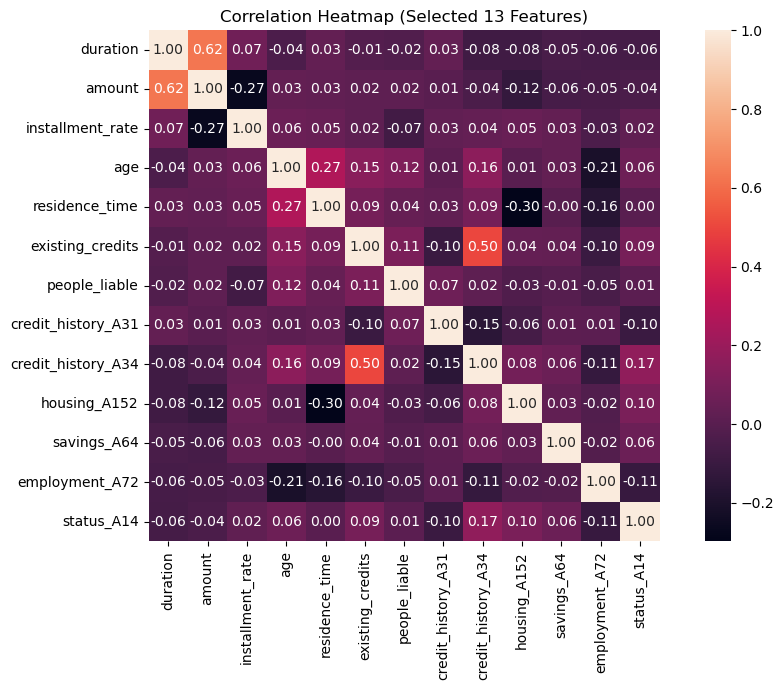

Saved to figures/


In [39]:
# FINAL VISUALIZATION SECTION
# Correlation Heatmap (Selected Features)
# This does NOT retrain anything. Safe to run.


import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)

corr = df_encoded[selected_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Correlation Heatmap (Selected 13 Features)")
plt.tight_layout()

plt.savefig("figures/correlation_heatmap_selected_features.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Save correlation matrix to CSV
corr.to_csv("figures/correlation_matrix_selected_features.csv")

print("Saved to figures/")


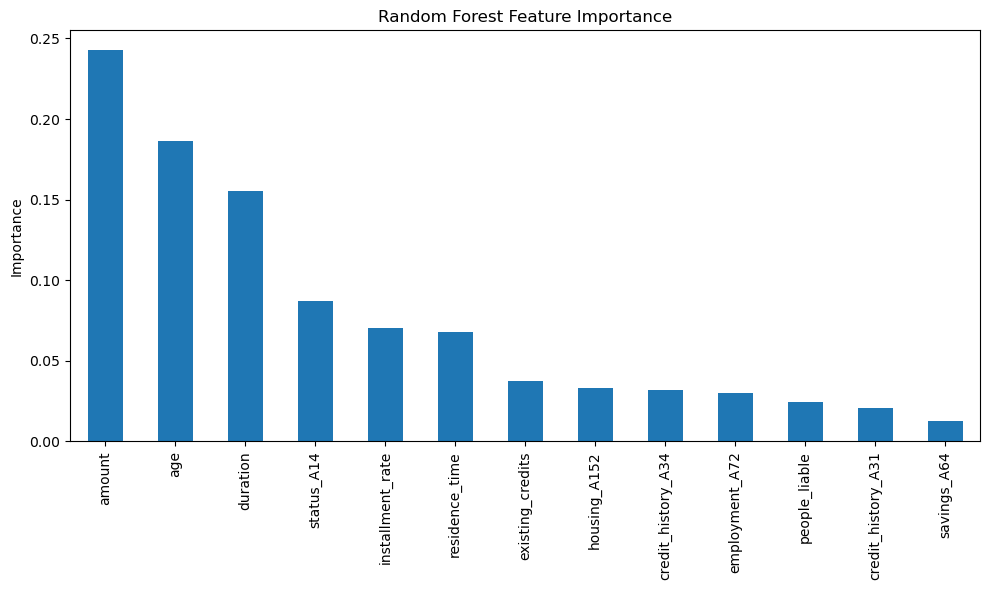

,importance
amount,0.242920
age,0.186307
duration,0.155088
status_A14,0.086934
installment_rate,0.070598
residence_time,0.067996
existing_credits,0.037625
housing_A152,0.032893
credit_history_A34,0.031905
employment_A72,0.029918


Saved to figures/


In [40]:
# Random Forest Feature Importance
# Uses already-trained rf model

import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

importances = pd.Series(rf.feature_importances_, index=selected_features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()

plt.savefig("figures/rf_feature_importance.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Save CSV
importances.to_frame("importance").to_csv(
    "figures/rf_feature_importance.csv"
)

display(importances.to_frame("importance"))

print("Saved to figures/")


,Pred: Good (0),Pred: Bad (1)
Actual: Good (0),90,50
Actual: Bad (1),13,47


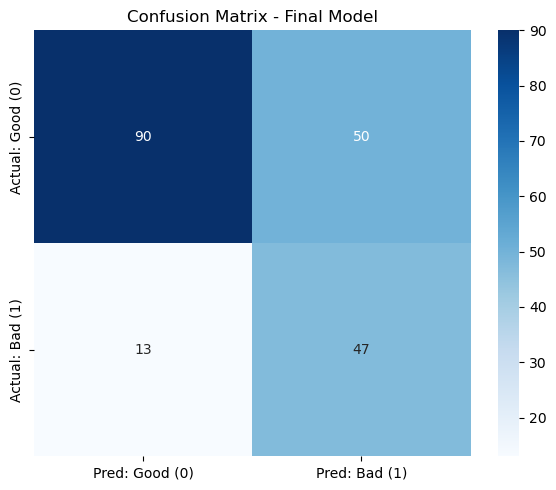

Saved to figures/


In [41]:
# Clean Confusion Matrix Table (Final Model Example: SVM_balanced)
# Change cm_* variable depending on final model


import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

cm_table = pd.DataFrame(
    cm_svm_bal,  
    index=["Actual: Good (0)", "Actual: Bad (1)"],
    columns=["Pred: Good (0)", "Pred: Bad (1)"]
)

display(cm_table)

# Save table
cm_table.to_csv("figures/final_confusion_matrix.csv")

# Optional: also save heatmap version
plt.figure(figsize=(6,5))
sns.heatmap(cm_table, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Final Model")
plt.tight_layout()
plt.savefig("figures/final_confusion_matrix.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Saved to figures/")


In [42]:
import os

os.makedirs("figures", exist_ok=True)

importances.to_csv("figures/rf_feature_importance.csv")
cm_table.to_csv("figures/final_confusion_matrix.csv")

print("Files saved to figures/")

Files saved to figures/
